# **PyTesseract ve EASY OCR ile Karakter Tanıma**

- Bu derste PyTesseract kullanarak birkaç görüntü üzerinde OCR uygulayacağız
- Ayrıca Easy OCR kullanacağız

<img src="OCR.png" width="600">

OCR, Optical Character Recognition (Optik Karakter Tanıma) \
📌 Tanımı:\
Bir görüntüdeki (resim, taranmış belge, PDF vb.) yazıların bilgisayar tarafından okunup dijital, düzenlenebilir metne dönüştürülmesini sağlayan teknolojidir.\
Kullanım Alanları\
📑 Taranmış belgeleri Word veya PDF’e dönüştürmek\
📷 Fotoğraftaki yazıları almak (ör. ekran görüntüsü, fatura, tabela)\
🏦 Bankacılıkta çek/IBAN tanıma\
🚗 Plaka tanıma sistemleri\
📚 Eski kitapları dijitalleştirme

**“Tesseract”, İngilizcede dördüncü boyuttaki küpün (4D hypercube) adıdır.**\
Google’ın geliştirdiği Tesseract OCR yazılımına bu ismin verilmesinin sebebi:\
OCR probleminin karmaşık ve çok boyutlu bir problem olması,\
Yazının farklı font, boyut, eğim ve gürültü gibi birçok değişkeninin (boyutunun) olmasıdır.

# PyTesseract yükleyelim

In [62]:
# PyTesseract'ı yükleyelim
!pip install pytesseract

Defaulting to user installation because normal site-packages is not writeable


# Tesseract yükleyelim
https://github.com/UB-Mannheim/tesseract/wiki


In [74]:
import cv2
import pytesseract
import numpy as np
from matplotlib import pyplot as plt

pytesseract.pytesseract.tesseract_cmd = (
    r'/usr/bin/tesseract'
)

def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()


## **İlk OCR Denemesi**

In [78]:
# Öncelikle hata vermemesi için pytesseract yüklenen yolu bilgisayarımıza gösterelim
import pytesseract
# Başka bir yere kurulduysa aşağıdaki yolu güncelleyin
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"


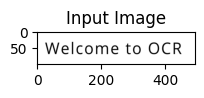

PyTesseract Extracted: Welcome to OCR



In [82]:
img = cv2.imread('../files/images/OCR1.png')
imshow("Input Image", img)

# PyTesseract aracılığıyla görüntümüzü analiz edelim
output_txt = pytesseract.image_to_string(img)

print("PyTesseract Extracted: {}".format(output_txt))

## **Siyah zeminler üzerinde beyaz metin okunabilir mi?**

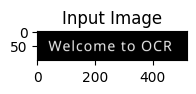

PyTesseract Extracted: Welcome to OCR



In [89]:
img = cv2.imread('../files/images/OCR2.png')
imshow("Input Image", img)

# PyTesseract aracılığıyla görüntümüzü analiz edelim
output_txt = pytesseract.image_to_string(img)

print("PyTesseract Extracted: {}".format(output_txt))

## **Daha karmaşık arka planlarda okuma**

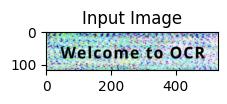

PyTesseract Extracted: 


In [91]:
img = cv2.imread('../files/images/OCR3.png')
imshow("Input Image", img)

# PyTesseract aracılığıyla görüntümüzü analiz edelim
output_txt = pytesseract.image_to_string(img)

print("PyTesseract Extracted: {}".format(output_txt))

## **What about a real life scan?**

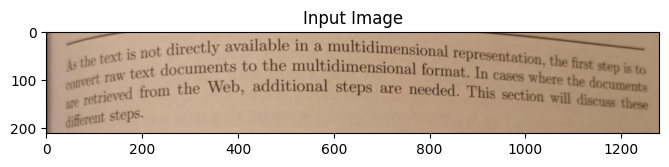

PyTesseract Extracted: directly avail
able i
le in a multidimensi
ional re
ion, the
7 first

As the text is not
convert raw text documents
: to th
are retrieved from e multidi
a the NEP, widicional sae a format
eps are at. In
need Cases
ed. This where the step is to
tion will discuss
these

different stePs-



In [94]:
img = cv2.imread('../files/images/scan2.jpeg')
imshow("Input Image", img, size = 48)

# PyTesseract aracılığıyla görüntümüzü analiz edelim
output_txt = pytesseract.image_to_string(img)

print("PyTesseract Extracted: {}".format(output_txt))

# **Resimde Düzeltme Yaparak**

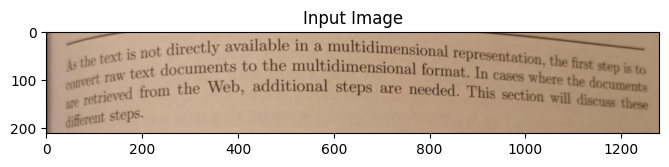

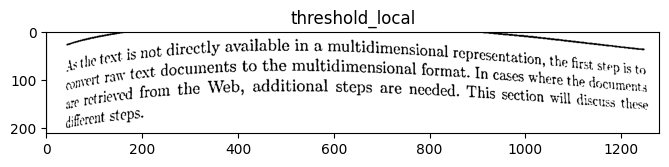

PyTesseract Extracted: ; ej multidimensional r
irectly available in a mu :
ne text is not direct nts to the multidimensional form
gs the aw text oy Web, additional steps are neede
om

Cpresentation, the first step is ta
at. In cases where the documents

d. This section will discuss these
convert n

gre ret rieved fr
diferent stePS-



In [103]:
from skimage.filters import threshold_local

image = cv2.imread('../files/images/scan2.jpeg')
imshow("Input Image", image, size = 48)

# Değer bileşenini HSV renk uzayından alıyoruz 
# sonra uyarlamalı eşikleme uyguluyoruz
V = cv2.split(cv2.cvtColor(image, cv2.COLOR_BGR2HSV))[2]
T = threshold_local(V, 25, offset=15, method="gaussian")

# Eşik işlemini uygulayalım
thresh = (V > T).astype("uint8") * 255
imshow("threshold_local", thresh, size = 48)

output_txt = pytesseract.image_to_string(thresh)
print("PyTesseract Extracted: {}".format(output_txt))

### **Eşikleme Daha iyi okuma sağlar**

Tipik olarak OCR tanıma için iyi bir ön işleme hattı aşağıdaki işlemlerden bazılarını veya daha fazlasını içerecektir:
1. Bluring (Bulanıklaştırma)
2. Thresholding (Eşkileme)
3. Deskewing (Eğim Düzeltme)
4. Dilation/Erosion/Opening/Closing (Dilatasyon/Erozyon/Açılma/Kapanma)
5. Noise Removal (Gürültü Giderme)

### **PyTesseract Tarafından Tanınan Bölgeler Üzerinde Çizim Yapalım**

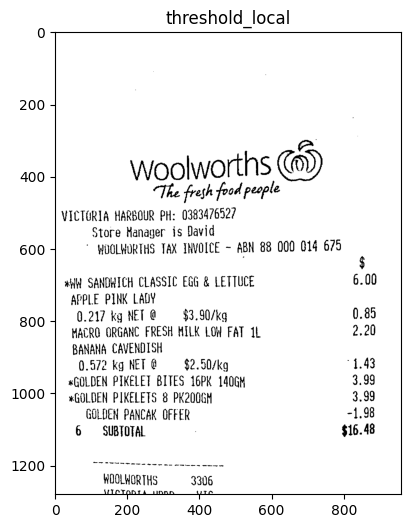

PyTesseract Extracted: o
Woolworths @)
The fresh food people
VICTORIA HARBOUR PH: 0383476527

Store Manager is David
" WOOLWORTHS TAX INVOICE - ABN 88 000 014 675

wh SANDWICH CLASSIC EGG & LETTUCE 6.00
APPLE PINK LAUY
0.217 kg NET@ = $3.90/kg 0.85
HACRO ORGANC FRESH MILK LOW FAT IL 2.20
BANANA CAVENDISH
0.572 kg NET @ = $2. 50/kg “1.43
GOLDEN PIKELET BITES 16PK 140GH 3.99
GOLDEN PIKELETS 8 PK2OOGH 3.99
GOLDEN PANCAK OFFER -1,98
6 = SUBTOTAL $16.48

WOOLWORTHS 3306

TITATANYT A pAnrR



In [118]:
from skimage.filters import threshold_local

image = cv2.imread('../files/images/Receipt-woolworth.jpg')

# We get the Value component from the HSV color space 
# then we apply adaptive thresholdingto 
V = cv2.split(cv2.cvtColor(image, cv2.COLOR_BGR2HSV))[2]
T = threshold_local(V, 25, offset=15, method="gaussian")

# Apply the threshold operation 
thresh = (V > T).astype("uint8") * 255
imshow("threshold_local", thresh,6)

output_txt = pytesseract.image_to_string(thresh)
print("PyTesseract Extracted: {}".format(output_txt))

In [110]:
from pytesseract import Output

d = pytesseract.image_to_data(thresh, output_type = Output.DICT)
print(d.keys())

dict_keys(['level', 'page_num', 'block_num', 'par_num', 'line_num', 'word_num', 'left', 'top', 'width', 'height', 'conf', 'text'])


### Bu sözlüğü kullanarak, tespit edilen her kelimeyi, sınırlayıcı kutu bilgilerini, içlerindeki metni ve her biri için güven puanlarını alabiliriz.


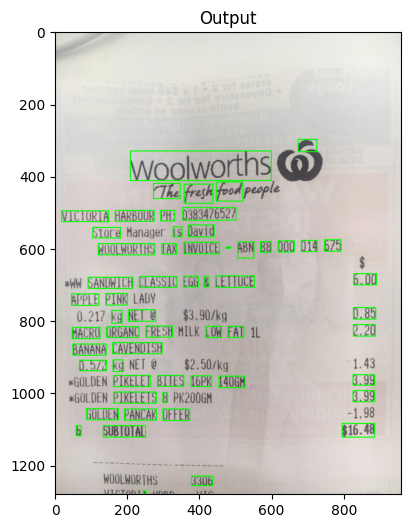

In [116]:
n_boxes = len(d['text'])

for i in range(n_boxes):
    if int(d['conf'][i]) > 60:
        (x, y, w, h) = (d['left'][i], d['top'][i], d['width'][i], d['height'][i])
        image = cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)

imshow('Output', image, size = 6)


## **EASY OCR**

In [120]:
!pip install easyocr

Defaulting to user installation because normal site-packages is not writeable


**Resimdeki Metni Algıla ve Girdi Resmini Göster**

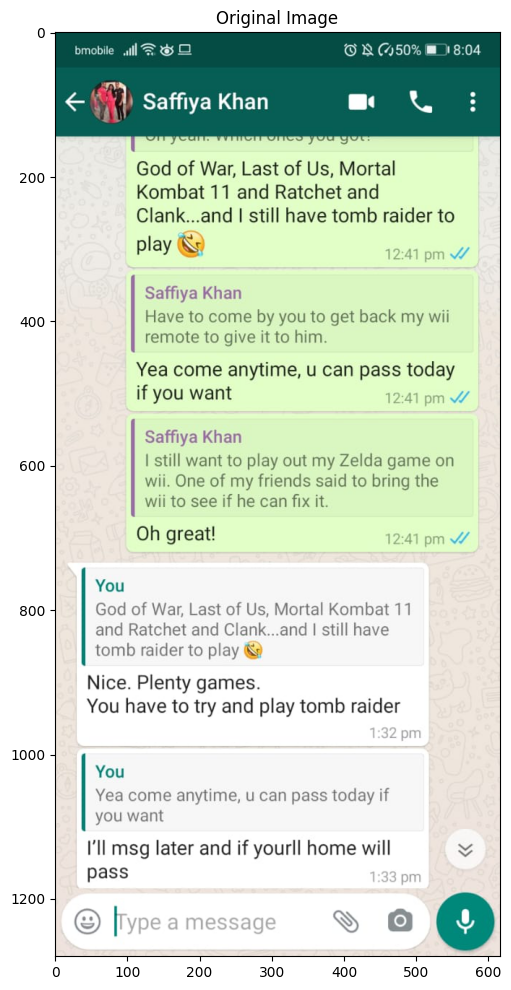

Using CPU. Note: This module is much faster with a GPU.


Detecting and OCR'ing text from input image...
Completed in 13.522895097732544 seconds
Tamamlandı


In [131]:
# gerekli paketleri içe aktaralım
from matplotlib import pyplot as plt
from easyocr import Reader
import pandas as pd
import cv2
import time

# imshow fonksiyonumuzu tanımlayalım
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

# girdi görüntüsünü yükleyelim
image = cv2.imread("../files/images/whatsapp_conv.jpeg")
imshow("Original Image", image, size = 12)

# EasyOCR kullanarak giriş görüntüsünü OCR
print("Detecting and OCR'ing text from input image...")
reader = Reader(['en'], gpu = False)

ts = time.time()
results = reader.readtext(image)
te = time.time()
td = te - ts
print(f'Completed in {td} seconds')
print("Tamamlandı")

In [133]:
results

[([[24, 12], [192, 12], [192, 38], [24, 38]],
  'bmobile _ill < 82',
  0.10449319329936473),
 ([[396, 12], [510, 12], [510, 38], [396, 38]],
  "'0 ^ (50%",
  0.8393076414329291),
 ([[546, 12], [594, 12], [594, 36], [546, 36]], '8.04', 0.9925435185432434),
 ([[113, 72], [302, 72], [302, 123], [113, 123]],
  'Saffiya Khan',
  0.5369110660469322),
 ([[110, 174], [200, 174], [200, 204], [110, 204]],
  'God of',
  0.9896150964856332),
 ([[254, 173], [476, 173], [476, 206], [254, 206]],
  'Last of Us, Mortal',
  0.8924645006654606),
 ([[110, 206], [454, 206], [454, 238], [110, 238]],
  'Kombat 11 and Ratchet and',
  0.7597694123884997),
 ([[110, 240], [250, 240], [250, 270], [110, 270]],
  'Clank__and',
  0.7667971789868723),
 ([[264, 238], [558, 238], [558, 270], [264, 270]],
  'still have tomb raider to',
  0.9739754333213781),
 ([[107, 279], [167, 279], [167, 315], [107, 315]],
  'play',
  0.8878526934329297),
 ([[452, 294], [544, 294], [544, 322], [452, 322]],
  '12.41 pm',
  0.649520967

## **Resmimizin Üzerine Yerleştirilmiş Metni Göster**

 Probability of Text: 10.449% OCR'd Text: bmobile _ill < 82
 Probability of Text: 83.931% OCR'd Text: '0 ^ (50%
 Probability of Text: 99.254% OCR'd Text: 8.04
 Probability of Text: 53.691% OCR'd Text: Saffiya Khan
 Probability of Text: 98.962% OCR'd Text: God of
 Probability of Text: 89.246% OCR'd Text: Last of Us, Mortal
 Probability of Text: 75.977% OCR'd Text: Kombat 11 and Ratchet and
 Probability of Text: 76.680% OCR'd Text: Clank__and
 Probability of Text: 97.398% OCR'd Text: still have tomb raider to
 Probability of Text: 88.785% OCR'd Text: play
 Probability of Text: 64.952% OCR'd Text: 12.41 pm
 Probability of Text: 99.964% OCR'd Text: Saffiya Khan
 Probability of Text: 57.068% OCR'd Text: Have to come by you to get back my wii
 Probability of Text: 54.613% OCR'd Text: remote to give it to him:
 Probability of Text: 74.487% OCR'd Text: Yea come anytime, U can pass today
 Probability of Text: 98.359% OCR'd Text: if you want
 Probability of Text: 70.253% OCR'd Text: 12.41 pm
 Pr

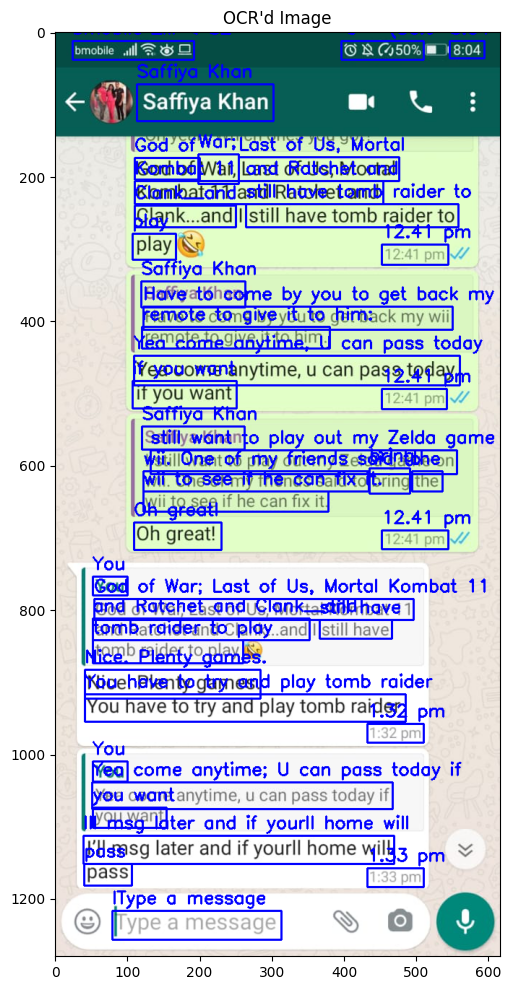

In [137]:
all_text = []

# iterate over our extracted text 
for (bbox, text, prob) in results:
    # display the OCR'd text and the associated probability of it being text
    print(f" Probability of Text: {prob*100:.3f}% OCR'd Text: {text}")

    # get the bounding box coordinates
    (tl, tr, br, bl) = bbox
    tl = (int(tl[0]), int(tl[1]))
    tr = (int(tr[0]), int(tr[1]))
    br = (int(br[0]), int(br[1]))
    bl = (int(bl[0]), int(bl[1]))

    # Remove non-ASCII characters from the text so that
    # we can draw the box surrounding the text overlaid onto the original image
    text = "".join([c if ord(c) < 128 else "" for c in text]).strip()
    all_text.append(text)
    cv2.rectangle(image, tl, br, (255, 0, 0), 2)
    cv2.putText(image, text, (tl[0], tl[1] - 10),
      cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

# show the output image
imshow("OCR'd Image", image, size = 12)

## **WoolWorth Reciept'i üzerinde çalıştıralım**

Using CPU. Note: This module is much faster with a GPU.


[INFO] 0.0000: 
[INFO] 0.0000: 
[INFO] 0.0000: 
[INFO] 0.0068: 800
[INFO] 0.9213: Woolworths
[INFO] 0.2296: The fregh food
[INFO] 0.6164: VICIURIA HARBOUR PH:  0383476527
[INFO] 0.7185: Store Hanager
[INFO] 0.6325: i$ ٥avid
[INFO] 0.3334: WUULWURIHS TAX INVOICE
[INFO] 0.6725: ABN 88 000 014 675
[INFO] 0.9711: $
[INFO] 0.1758: *Ah SANDHICH CLASSIC EGG & LETIUCE
[INFO] 0.8745: 6. 00
[INFO] 0.6487: AFPLE PINK LALV
[INFO] 0.2598: 0. 217 kg N٤٢
[INFO] 0.9519: $3. 90/k9
[INFO] 0.7346: 0. 85
[INFO] 0.4177: HACRO ORGANC FRESH HILK LOW FAT 1l
[INFO] 0.5283: 2. 20
[INFO] 0.8945: BANANA CAVENDISH
[INFO] 0.2964: 0. 572 k ٤٢
[INFO] 0.3659: 0
[INFO] 0.9914: $2
[INFO] 0.9854: 1. 43
[INFO] 0.5604: *GULDEN PIKELEI BIES 16PK 14OGH
[INFO] 0.9263: 3. 99
[INFO] 0.3290: »GOLIEN PIKELETS 8 PKZUUIH
[INFO] 0.9797: 3. 99
[INFO] 0.3624: fULILN PANCAK OFFER
[INFO] 0.1682: ٥
[INFO] 0.3123: SUBTUTAL
[INFO] 0.9974: $16.48
[INFO] 0.1623: MOOLMORIHS
[INFO] 0.9998: 3306
[INFO] 0.1721: ٢ ٢١ ٢ ٢ ٨ ١١٢ 
[INFO] 0.0000: 
[I

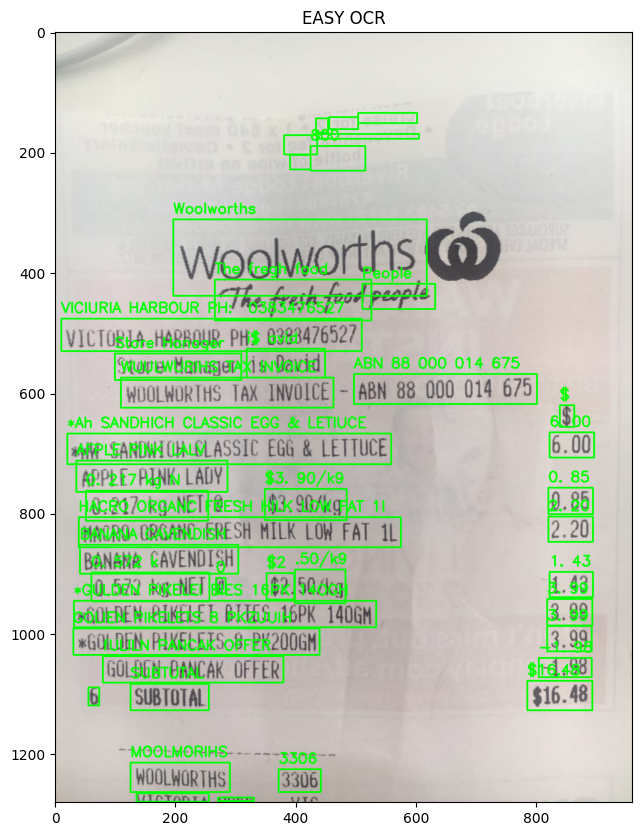

EASY OCR Extracted: -1. 98


In [142]:
import cv2
from easyocr import Reader
import numpy as np
from matplotlib import pyplot as plt

# imshow fonksiyonumuzu tanımlayın 
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

def clean_text(text):
	# ASCII olmayan metni kaldıalım, böylece metni görüntü üzerine yazabiliriz
	return "".join([c if ord(c) < 128 else "" for c in text]).strip()

image = cv2.imread('../files/images/Receipt-woolworth.jpg')

reader = Reader(["en","ar"], gpu=False)
results = reader.readtext(image)

# sonuçlar üzerinde döngü
for (bbox, text, prob) in results:
	# OCR'lanan metni ve olasılığı görüntüleyelim
	print("[INFO] {:.4f}: {}".format(prob, text))

	# sınırlayıcı kutuyu işleyelim
	(tl, tr, br, bl) = bbox
	tl = (int(tl[0]), int(tl[1]))
	tr = (int(tr[0]), int(tr[1]))
	br = (int(br[0]), int(br[1]))
	bl = (int(bl[0]), int(bl[1]))

	# metni temizleyin ve metni çevreleyen kutuyu birlikte çizin
	text = clean_text(text)
	cv2.rectangle(image, tl, br, (0, 255, 0), 2)
	cv2.putText(image, text, (tl[0], tl[1] - 10),
		cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

# Eşik işlemini uygulayalım
#thresh = (V > T).astype("uint8") * 255
imshow("EASY OCR", image)
print("EASY OCR Extracted: {}".format(text))